<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/InferentialDS1_extracted.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CaO content Inferential DS1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

sns.set()
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
sklearn.__version__

'1.6.1'

Read from Google Drive

In [ ]:
from google.colab import files
import pandas as pd


uploaded = files.upload()


#df = pd.read_csv('CaODS1.csv', sep='\t')   # <-- plik oddzielany tabulatorem
df_raw = pd.read_csv('CaODS1.csv', sep=',')   # <-- plik oddzielany przecinkiem
print("Data loaded correctly!\n")
print(df_raw.head())

Saving CaODS1.csv to CaODS1.csv
Data loaded correctly!

         Date   Time  \
0  10/16/2025  3:0:0   
1  10/16/2025  3:0:1   
2  10/16/2025  3:0:2   
3  10/16/2025  3:0:3   
4  10/16/2025  3:0:4   

   CAO_DS.LABUPDATE_LABVALUE_1/Var/CV/CAO_DS.LABUPDATE_LABVALUE_1 History data/  \
0                                                 29                              
1                                                 29                              
2                                                 29                              
3                                                 29                              
4                                                 29                              

   CAO_DS.CAO_DS1_5/Var/CV/CAO_DS.CAO_DS1_5 History data/  \
0                                          51.065129        
1                                          51.065129        
2                                          51.065129        
3                                          51.065129    

Kopiuj i zmien nazwy kolumn

In [ ]:
# 1. Utworzenie kopii danych
df = df_raw.copy()

# mapa starych nazw na nowe
rename_map = {
    'CAO_DS.LABUPDATE_LABVALUE_1/Var/CV/CAO_DS.LABUPDATE_LABVALUE_1 History data/': 'LabUpdate',
    'CAO_DS.CAO_DS1_5/Var/CV/CAO_DS.CAO_DS1_5 History data/': 'Inferential',
    'DISTIL._CV19.READVALUE/Var/CV/DISTIL._CV19.READVALUE History data/': 'Ratio',
    'DISTIL._CV24.READVALUE/Var/CV/DISTIL._CV24.READVALUE History data/': 'pH',
    'DISTIL._CV25.READVALUE/Var/CV/DISTIL._CV25.READVALUE History data/': 'CMFlow'
}

# zmiana nazw kolumn
df_raw = df_raw.rename(columns=rename_map)

# szybkie sprawdzenie
#print(df_raw.columns)

# 3. Podgląd pierwszych wierszy
print(df.head())

         Date   Time  LabUpdate  Inferential     Ratio        pH     CMFlow
0  10/16/2025  3:0:0         29    51.065129  0.384064  9.113763  51.057755
1  10/16/2025  3:0:1         29    51.065129  0.384064  9.113763  51.057755
2  10/16/2025  3:0:2         29    51.065129  0.384064  9.113763  51.057755
3  10/16/2025  3:0:3         29    51.065129  0.384064  9.113763  51.057755
4  10/16/2025  3:0:4         29    51.065129  0.384064  9.113763  51.057755


Trend surowych

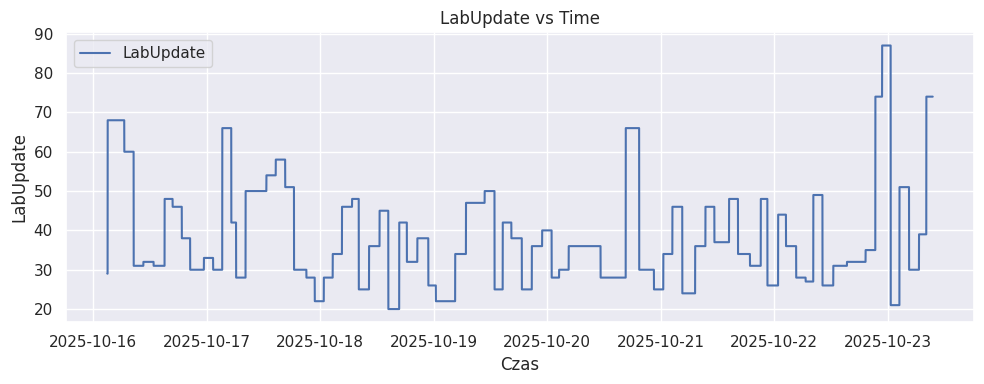

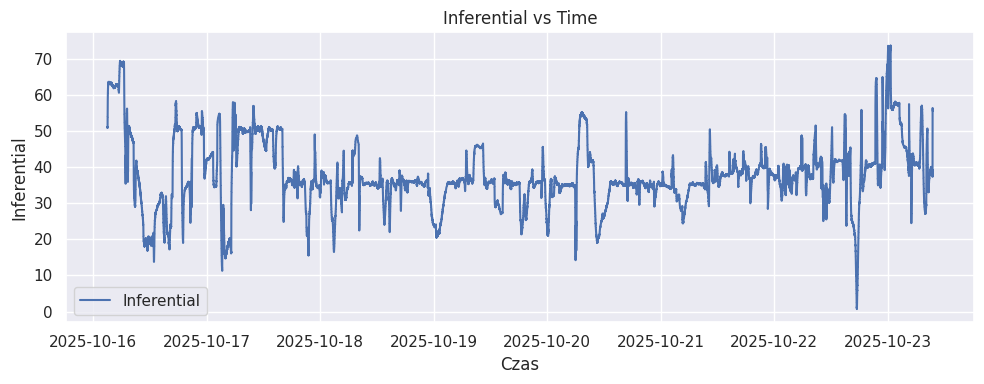

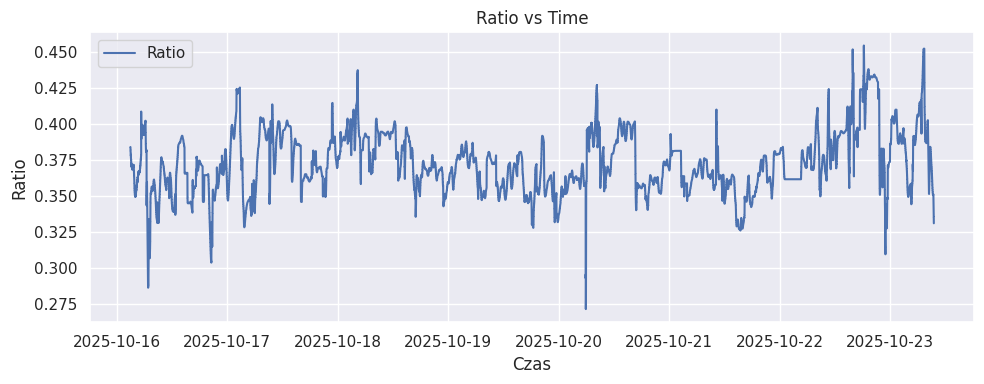

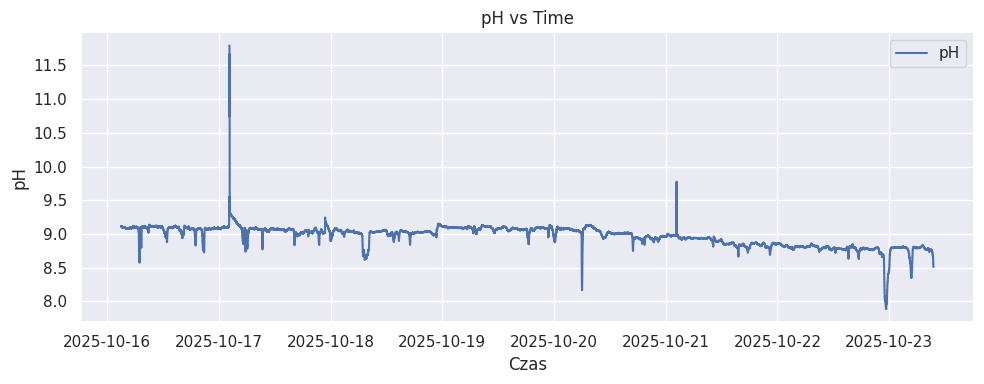

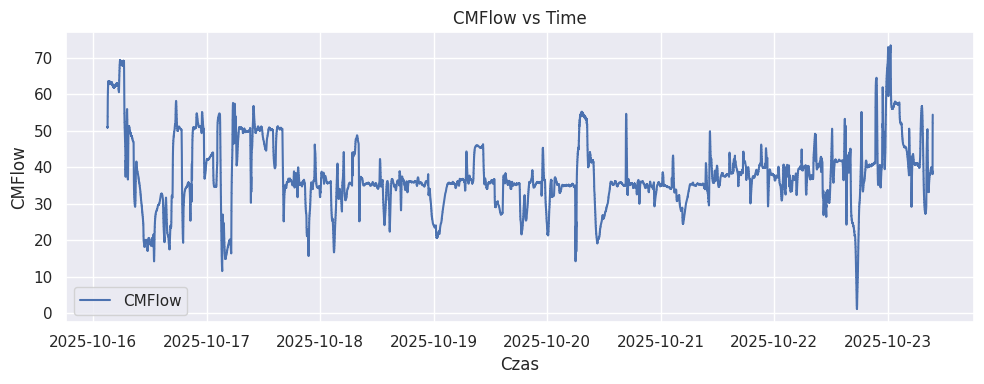

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Połączenie daty i czasu w jedną kolumnę typu datetime
df_raw['DATETIME'] = pd.to_datetime(df_raw['Date'].astype(str) + ' ' + df_raw['Time'].astype(str))

# Ustawienie DATETIME jako indeks czasu
df_raw = df_raw.set_index('DATETIME')

# Lista kolumn do rysowania
cols = ['LabUpdate', 'Inferential', 'Ratio', 'pH', 'CMFlow']

# Tworzymy wykresy osobno dla każdej kolumny
for col in cols:
    plt.figure(figsize=(10, 4))
    plt.plot(df_raw.index, df_raw[col], label=col, linewidth=1.5)
    plt.title(f'{col} vs Time')
    plt.xlabel('Czas')
    plt.ylabel(col)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Ekstrakcja

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Przygotowanie danych wejściowych
# =========================

df = df_raw.copy()

# --- Usuń ewentualny stary indeks DATETIME lub kolumnę o tej samej nazwie ---
if 'DATETIME' in df.columns:
    df = df.drop(columns='DATETIME')

if df.index.name == 'DATETIME':
    df = df.reset_index()

# --- Zbuduj nową kolumnę czasową ---
df['DATETIME'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    errors='coerce'
)

# --- Ustaw poprawny indeks czasowy ---
df = df.sort_values('DATETIME').set_index('DATETIME')

# --- Zachowaj tylko interesujące kolumny ---
df = df[['LabUpdate', 'Inferential', 'Ratio', 'pH', 'CMFlow']]

# =========================
# 2. Wykrywanie momentów zmiany LabUpdate
# =========================

df['LabChangeFlag'] = df['LabUpdate'].ne(df['LabUpdate'].shift())
change_times = df.index[df['LabChangeFlag']].to_list()

# =========================
# 3. Funkcja pomocnicza: statystyki w oknie ±10s
# =========================

def extract_window_stats(df_window):
    out = {}
    vars_process = ['Inferential', 'Ratio', 'pH', 'CMFlow']
    for var in vars_process:
        s = df_window[var].dropna()
        out[f'{var}_avg'] = s.mean()
        out[f'{var}_med'] = s.median()
    return out

# =========================
# 4. Iteracja po zmianach LabUpdate
# =========================

rows = []

for t_change in change_times:
    t_start = t_change - pd.Timedelta(seconds=100)
    t_end   = t_change + pd.Timedelta(seconds=100)
    window_df = df.loc[(df.index >= t_start) & (df.index <= t_end)]

    if len(window_df) == 0:
        continue

    stats_dict = extract_window_stats(window_df)
    lab_val = df.loc[t_change, 'LabUpdate']

    row = {'ChangeTime': t_change, 'LabUpdate': lab_val}
    row.update(stats_dict)
    rows.append(row)

# =========================
# 5. Zbuduj końcowy df_ext
# =========================

df_ext = pd.DataFrame(rows).sort_values('ChangeTime').reset_index(drop=True)

print("✅ df_ext – pierwsze wiersze:\n")
print(df_ext.head(), "\n")

print("📊 Opis statystyczny:\n")
print(df_ext.describe(include='all'))

print(df_ext.head())

✅ df_ext – pierwsze wiersze:

           ChangeTime  LabUpdate  Inferential_avg  Inferential_med  Ratio_avg  \
0 2025-10-16 03:00:00         29        51.050971        51.064675   0.382814   
1 2025-10-16 03:02:30         68        52.716789        51.086988   0.380589   
2 2025-10-16 06:33:30         60        62.417553        63.746540   0.355859   
3 2025-10-16 08:32:30         31        44.393719        46.672949   0.342781   
4 2025-10-16 10:35:40         32        23.317020        23.991943   0.357975   

   Ratio_med    pH_avg    pH_med  CMFlow_avg  CMFlow_med  
0   0.382889  9.113824  9.113763   51.050763   51.064674  
1   0.380293  9.113029  9.113763   52.384711   51.075890  
2   0.356622  9.092202  9.092872   62.594202   64.000793  
3   0.342676  9.090918  9.092872   45.917518   46.836266  
4   0.357905  9.116514  9.113763   24.136728   24.367920   

📊 Opis statystyczny:

                          ChangeTime  LabUpdate  Inferential_avg  \
count                             78 

Wykresy XY

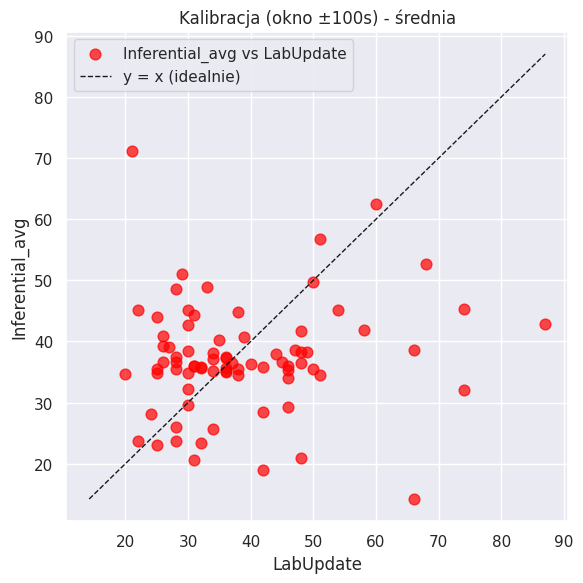

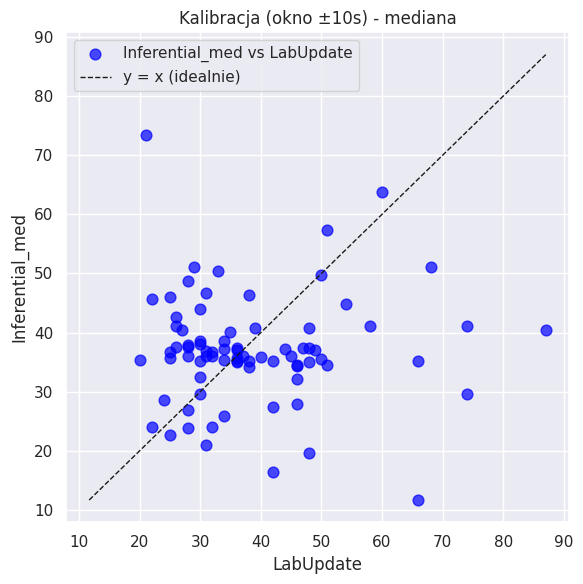

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Wykres 1: średnia (avg) ---
plt.figure(figsize=(6,6))
plt.scatter(
    df_ext['LabUpdate'],
    df_ext['Inferential_avg'],
    color='red',
    alpha=0.7,
    label='Inferential_avg vs LabUpdate',
    s=60
)

# linia idealna y = x
min_val = np.nanmin([df_ext['LabUpdate'].min(), df_ext['Inferential_avg'].min()])
max_val = np.nanmax([df_ext['LabUpdate'].max(), df_ext['Inferential_avg'].max()])
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='y = x (idealnie)')

plt.title('Kalibracja (okno ±100s) - średnia')
plt.xlabel('LabUpdate')
plt.ylabel('Inferential_avg')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# --- Wykres 2: mediana (med) ---
plt.figure(figsize=(6,6))
plt.scatter(
    df_ext['LabUpdate'],
    df_ext['Inferential_med'],
    color='blue',
    alpha=0.7,
    label='Inferential_med vs LabUpdate',
    s=60
)

# linia idealna y = x
min_val = np.nanmin([df_ext['LabUpdate'].min(), df_ext['Inferential_med'].min()])
max_val = np.nanmax([df_ext['LabUpdate'].max(), df_ext['Inferential_med'].max()])
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='y = x (idealnie)')

plt.title('Kalibracja (okno ±10s) - mediana')
plt.xlabel('LabUpdate')
plt.ylabel('Inferential_med')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Odrzucenie błędnych wyników

Ile punktów po filtrze (AVG): 66  / przed: 78
Ile punktów po filtrze (MED): 66  / przed: 78


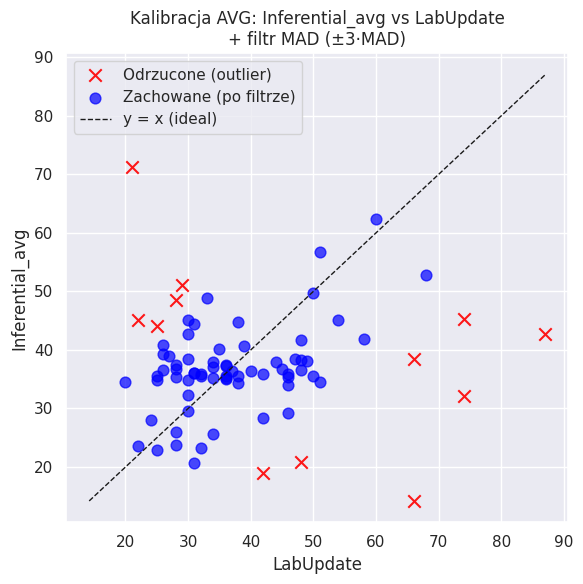

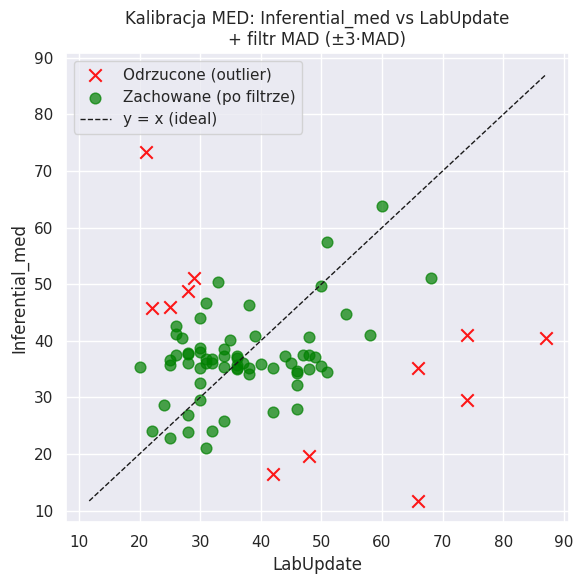


📊 Raport jakości po filtracji MAD (AVG):
     metryka: Inferential_avg
     N_przed: 78
        N_po: 66
   MAE_przed: 11.1478
      MAE_po: 7.4318
   MSE_przed: 241.0585
      MSE_po: 79.5058
  bias_przed: -1.5370
     bias_po: -0.1594
    R2_przed: 0.0112
       R2_po: 0.2587

📊 Raport jakości po filtracji MAD (MED):
     metryka: Inferential_med
     N_przed: 78
        N_po: 66
   MAE_przed: 11.8692
      MAE_po: 7.9282
   MSE_przed: 271.5470
      MSE_po: 90.2600
  bias_przed: -1.6964
     bias_po: -0.1438
    R2_przed: 0.0001
       R2_po: 0.1936


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels import robust

# =====================================================
# 1. Przygotowanie df_ext do analizy jakości
#    Zakładamy, że df_ext zawiera co najmniej:
#    ['LabUpdate', 'Inferential_avg', 'Inferential_med']
# =====================================================

df_ext = df_ext.copy()

# błędy modelu (różnica pomiar on-line vs lab)
df_ext['error_avg'] = df_ext['Inferential_avg'] - df_ext['LabUpdate']
df_ext['error_med'] = df_ext['Inferential_med'] - df_ext['LabUpdate']


# =====================================================
# 2. Filtr punktów niepewnych metodą MAD (Median Absolute Deviation)
#    MAD jest odporny na pojedyncze odjechane punkty i szum procesowy
# =====================================================

def mad_filter(series, k=3.0):
    """
    series: pd.Series z błędem (np. Inferential_avg - LabUpdate)
    k: próg w jednostkach MAD (typowo 3.0)

    Zwraca maskę bool (True = punkt OK, False = punkt odrzucony jako outlier).
    """
    # usuwamy NaN-y tylko do obliczenia mediany i MAD
    valid = series.dropna()

    # mediana błędu
    med = np.nanmedian(valid)

    # MAD skalowany do odpowiednika sigma Gaussa
    # robust.mad zwraca median(|x - median(x)|) * c
    mad_val = robust.mad(valid, c=1.4826)

    # domyślnie wszyscy True
    mask = pd.Series(True, index=series.index)

    # jeżeli MAD == 0 lub NaN (czyli dane są niemal identyczne), to nie odrzucamy nic
    if mad_val == 0 or np.isnan(mad_val):
        return mask

    # odrzucamy punkty, które są za daleko od mediany błędu
    mask[:] = np.abs(series - med) < k * mad_val
    return mask


# maski jakości osobno dla wersji AVG i MED
mask_avg = mad_filter(df_ext['error_avg'], k=3.0)
mask_med = mad_filter(df_ext['error_med'], k=3.0)

# tworzymy oczyszczone DataFrame'y
df_clean_avg = df_ext[mask_avg].copy()
df_clean_med = df_ext[mask_med].copy()

# punkty odrzucone (do wizualizacji)
df_out_avg = df_ext[~mask_avg].copy()
df_out_med = df_ext[~mask_med].copy()

print("Ile punktów po filtrze (AVG):", len(df_clean_avg), " / przed:", len(df_ext))
print("Ile punktów po filtrze (MED):", len(df_clean_med), " / przed:", len(df_ext))


# =====================================================
# 3. Wykres kalibracji dla AVG
#    oś x = LabUpdate, oś y = Inferential_avg
#    pokazujemy punkty zachowane i wyrzucone
# =====================================================

plt.figure(figsize=(6,6))

# najpierw outliery (czerwone X)
if len(df_out_avg) > 0:
    plt.scatter(
        df_out_avg['LabUpdate'],
        df_out_avg['Inferential_avg'],
        color='red',
        marker='x',
        s=80,
        alpha=0.9,
        label='Odrzucone (outlier)'
    )

# punkty zaakceptowane (niebieskie kółka)
plt.scatter(
    df_clean_avg['LabUpdate'],
    df_clean_avg['Inferential_avg'],
    color='blue',
    s=60,
    alpha=0.7,
    label='Zachowane (po filtrze)'
)

# linia idealna y = x (perfekcyjne dopasowanie online=lab)
min_val = np.nanmin([
    df_ext['LabUpdate'].min(),
    df_ext['Inferential_avg'].min()
])
max_val = np.nanmax([
    df_ext['LabUpdate'].max(),
    df_ext['Inferential_avg'].max()
])
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    linewidth=1,
    label='y = x (ideal)'
)

plt.title('Kalibracja AVG: Inferential_avg vs LabUpdate\n+ filtr MAD (±3·MAD)')
plt.xlabel('LabUpdate')
plt.ylabel('Inferential_avg')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# =====================================================
# 4. Wykres kalibracji dla MED
#    oś x = LabUpdate, oś y = Inferential_med
# =====================================================

plt.figure(figsize=(6,6))

# outliery (czerwone X)
if len(df_out_med) > 0:
    plt.scatter(
        df_out_med['LabUpdate'],
        df_out_med['Inferential_med'],
        color='red',
        marker='x',
        s=80,
        alpha=0.9,
        label='Odrzucone (outlier)'
    )

# punkty zaakceptowane (zielone kółka)
plt.scatter(
    df_clean_med['LabUpdate'],
    df_clean_med['Inferential_med'],
    color='green',
    s=60,
    alpha=0.7,
    label='Zachowane (po filtrze)'
)

# linia idealna y = x
min_val2 = np.nanmin([
    df_ext['LabUpdate'].min(),
    df_ext['Inferential_med'].min()
])
max_val2 = np.nanmax([
    df_ext['LabUpdate'].max(),
    df_ext['Inferential_med'].max()
])
plt.plot(
    [min_val2, max_val2],
    [min_val2, max_val2],
    'k--',
    linewidth=1,
    label='y = x (ideal)'
)

plt.title('Kalibracja MED: Inferential_med vs LabUpdate\n+ filtr MAD (±3·MAD)')
plt.xlabel('LabUpdate')
plt.ylabel('Inferential_med')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# =====================================================
# 5. Raport jakości przed/po filtrowaniu
#    MAE, MSE, bias, R^2
# =====================================================

def quality_report(df_all, df_clean, pred_col):
    """
    df_all   : pełne dane (przed filtrem)
    df_clean : dane po filtrze
    pred_col : 'Inferential_avg' albo 'Inferential_med'
    """
    # błąd = pred - lab
    err_all = df_all[pred_col] - df_all['LabUpdate']
    err_cln = df_clean[pred_col] - df_clean['LabUpdate']

    # współczynnik determinacji R^2 (Pearson^2)
    def r2_like(a, b):
        if len(a) > 1 and len(b) > 1:
            return np.corrcoef(a, b)[0,1]**2
        else:
            return np.nan

    rep = {
        'metryka'      : pred_col,
        'N_przed'      : len(df_all),
        'N_po'         : len(df_clean),
        'MAE_przed'    : np.nanmean(np.abs(err_all)),
        'MAE_po'       : np.nanmean(np.abs(err_cln)),
        'MSE_przed'    : np.nanmean(err_all**2),
        'MSE_po'       : np.nanmean(err_cln**2),
        'bias_przed'   : np.nanmean(err_all),
        'bias_po'      : np.nanmean(err_cln),
        'R2_przed'     : r2_like(df_all['LabUpdate'], df_all[pred_col]),
        'R2_po'        : r2_like(df_clean['LabUpdate'], df_clean[pred_col]),
    }
    return rep

rep_avg = quality_report(df_ext, df_clean_avg, 'Inferential_avg')
rep_med = quality_report(df_ext, df_clean_med, 'Inferential_med')

print("\n📊 Raport jakości po filtracji MAD (AVG):")
for k, v in rep_avg.items():
    if isinstance(v, float):
        print(f"{k:>12}: {v:.4f}")
    else:
        print(f"{k:>12}: {v}")

print("\n📊 Raport jakości po filtracji MAD (MED):")
for k, v in rep_med.items():
    if isinstance(v, float):
        print(f"{k:>12}: {v:.4f}")
    else:
        print(f"{k:>12}: {v}")


Korelacja Lab Update i Inferential


🔹 Współczynnik korelacji Pearsona (AVG): 0.5086
🔹 Współczynnik korelacji Pearsona (MED): 0.4400


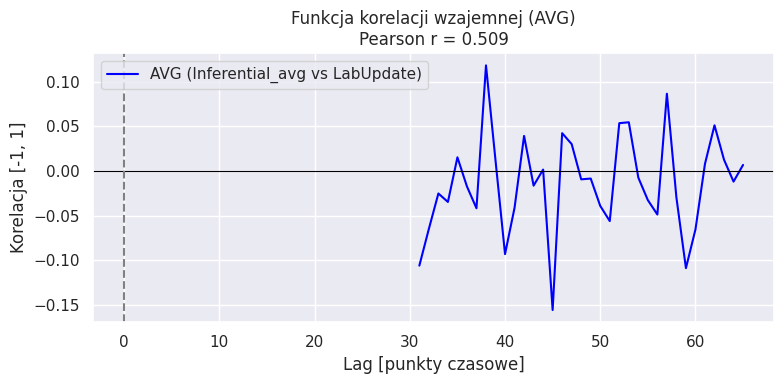

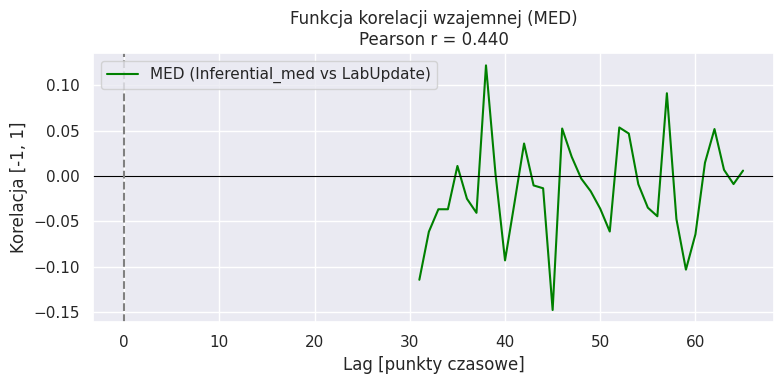

📈 Model AVG ma silniejszą liniową zależność z LabUpdate.
⚠️ AVG: maksimum korelacji występuje z przesunięciem w czasie.
⚠️ MED: maksimum korelacji występuje z przesunięciem w czasie.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. Funkcje pomocnicze
# =====================================================

def crosscorr_normalized(x, y, max_lag=None):
    """
    Oblicza znormalizowaną funkcję korelacji wzajemnej (w zakresie [-1, 1])
    """
    x = np.asarray(x) - np.nanmean(x)
    y = np.asarray(y) - np.nanmean(y)

    n = len(x)
    if max_lag is None:
        max_lag = n - 1

    corr = np.correlate(x, y, mode='full')
    corr /= np.nanstd(x) * np.nanstd(y) * n  # normalizacja
    lags = np.arange(-n + 1, n)
    center = len(corr) // 2
    idx = slice(center - max_lag, center + max_lag + 1)
    return lags[idx], corr[idx]


# =====================================================
# 2. Korelacja Pearsona
# =====================================================

corr_avg = df_clean_avg[['LabUpdate', 'Inferential_avg']].corr().iloc[0,1]
corr_med = df_clean_med[['LabUpdate', 'Inferential_med']].corr().iloc[0,1]

print(f"\n🔹 Współczynnik korelacji Pearsona (AVG): {corr_avg:.4f}")
print(f"🔹 Współczynnik korelacji Pearsona (MED): {corr_med:.4f}")


# =====================================================
# 3. Funkcje korelacji wzajemnej (cross-correlation)
# =====================================================

# --- AVG ---
lags_avg, corr_func_avg = crosscorr_normalized(
    df_clean_avg['LabUpdate'],
    df_clean_avg['Inferential_avg'],
    max_lag=100
)

# --- MED ---
lags_med, corr_func_med = crosscorr_normalized(
    df_clean_med['LabUpdate'],
    df_clean_med['Inferential_med'],
    max_lag=100
)


# =====================================================
# 4. Wykresy
# =====================================================

plt.figure(figsize=(8,4))
plt.plot(lags_avg, corr_func_avg, color='blue', label='AVG (Inferential_avg vs LabUpdate)')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--')
plt.title(f'Funkcja korelacji wzajemnej (AVG)\nPearson r = {corr_avg:.3f}')
plt.xlabel('Lag [punkty czasowe]')
plt.ylabel('Korelacja [-1, 1]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,4))
plt.plot(lags_med, corr_func_med, color='green', label='MED (Inferential_med vs LabUpdate)')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--')
plt.title(f'Funkcja korelacji wzajemnej (MED)\nPearson r = {corr_med:.3f}')
plt.xlabel('Lag [punkty czasowe]')
plt.ylabel('Korelacja [-1, 1]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# =====================================================
# 5. Wnioski (druk)
# =====================================================

if abs(corr_avg) > abs(corr_med):
    print("📈 Model AVG ma silniejszą liniową zależność z LabUpdate.")
else:
    print("📈 Model MED ma silniejszą liniową zależność z LabUpdate.")

if np.argmax(np.abs(corr_func_avg)) == len(corr_func_avg)//2:
    print("➕ AVG: maksimum korelacji występuje przy zerowym opóźnieniu (brak przesunięcia).")
else:
    print("⚠️ AVG: maksimum korelacji występuje z przesunięciem w czasie.")

if np.argmax(np.abs(corr_func_med)) == len(corr_func_med)//2:
    print("➕ MED: maksimum korelacji występuje przy zerowym opóźnieniu (brak przesunięcia).")
else:
    print("⚠️ MED: maksimum korelacji występuje z przesunięciem w czasie.")


In [ ]:
# --- Podgląd danych po filtrze MAD (AVG) ---
print("📘 Zbiór df_clean_avg – dane po filtracji MAD:")
display(df_clean_avg.head(100))  # pierwsze 10 wierszy

print("\n📊 Informacje o strukturze danych:")
print(df_clean_avg.info())

print("\n📈 Podstawowe statystyki liczbowe:")
display(df_clean_avg.describe())

📘 Zbiór df_clean_avg – dane po filtracji MAD:


,ChangeTime,LabUpdate,Inferential_avg,Inferential_med,Ratio_avg,Ratio_med,pH_avg,pH_med,CMFlow_avg,CMFlow_med,error_avg,error_med
1,2025-10-16 03:02:30,68,52.716789,51.086988,0.380589,0.380293,9.113029,9.113763,52.384711,51.075890,-15.283211,-16.913012
2,2025-10-16 06:33:30,60,62.417553,63.746540,0.355859,0.356622,9.092202,9.092872,62.594202,64.000793,2.417553,3.746540
3,2025-10-16 08:32:30,31,44.393719,46.672949,0.342781,0.342676,9.090918,9.092872,45.917518,46.836266,13.393719,15.672949
4,2025-10-16 10:35:40,32,23.317020,23.991943,0.357975,0.357905,9.116514,9.113763,24.136728,24.367920,-8.682980,-8.008057
5,2025-10-16 12:45:30,31,20.612278,21.007409,0.340584,0.338621,9.017561,9.018521,21.072824,21.404186,-10.387722,-9.992591
...,...,...,...,...,...,...,...,...,...,...,...,...
69,2025-10-22 15:21:10,32,35.810713,36.700827,0.410185,0.410933,8.765192,8.770276,33.776858,34.078671,3.810713,4.700827
70,2025-10-22 19:17:30,35,40.211526,40.050809,0.438227,0.438268,8.782098,8.780723,39.851783,39.803432,5.211526,5.050809
74,2025-10-23 02:27:10,51,56.762327,57.413100,0.387047,0.386948,8.796699,8.796699,57.402580,57.578510,5.762327,6.413100
75,2025-10-23 04:29:00,30,45.059917,38.029393,0.357944,0.357957,8.596300,8.601298,42.772983,40.793915,15.059917,8.029393



📊 Informacje o strukturze danych:
<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 1 to 76
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ChangeTime       66 non-null     datetime64[ns]
 1   LabUpdate        66 non-null     int64         
 2   Inferential_avg  66 non-null     float64       
 3   Inferential_med  66 non-null     float64       
 4   Ratio_avg        66 non-null     float64       
 5   Ratio_med        66 non-null     float64       
 6   pH_avg           66 non-null     float64       
 7   pH_med           66 non-null     float64       
 8   CMFlow_avg       66 non-null     float64       
 9   CMFlow_med       66 non-null     float64       
 10  error_avg        66 non-null     float64       
 11  error_med        66 non-null     float64       
dtypes: datetime64[ns](1), float64(10), int64(1)
memory usage: 6.7 KB
None

📈 Podstawowe statystyki liczbowe:


,ChangeTime,LabUpdate,Inferential_avg,Inferential_med,Ratio_avg,Ratio_med,pH_avg,pH_med,CMFlow_avg,CMFlow_med,error_avg,error_med
count,66,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,2025-10-19 16:54:30.909090816,36.954545,36.795141,36.810721,0.369415,0.369379,8.971518,8.971384,36.831135,36.863383,-0.159405,-0.143825
min,2025-10-16 03:02:30,20.000000,20.612278,21.007409,0.306806,0.306751,8.596300,8.601298,21.072824,21.404186,-16.744561,-18.002229
25%,2025-10-18 01:12:55,30.000000,34.841395,34.708384,0.356445,0.356672,8.866258,8.866748,34.732446,34.478077,-8.353537,-8.070810
50%,2025-10-19 15:29:10,34.500000,36.172216,36.109264,0.365205,0.365215,9.017246,9.016063,36.181700,36.117065,0.441691,0.367322
75%,2025-10-21 13:38:57.500000,45.750000,38.886998,38.645196,0.382222,0.382230,9.074575,9.075512,39.504301,39.499082,5.624627,6.263254
max,2025-10-23 06:35:00,68.000000,62.417553,63.746540,0.438227,0.438268,9.116514,9.113763,62.594202,64.000793,15.875388,17.348095
std,NaN,10.089495,7.420471,7.526948,0.021620,0.021702,0.122448,0.122411,7.488978,7.566658,8.983497,9.572231


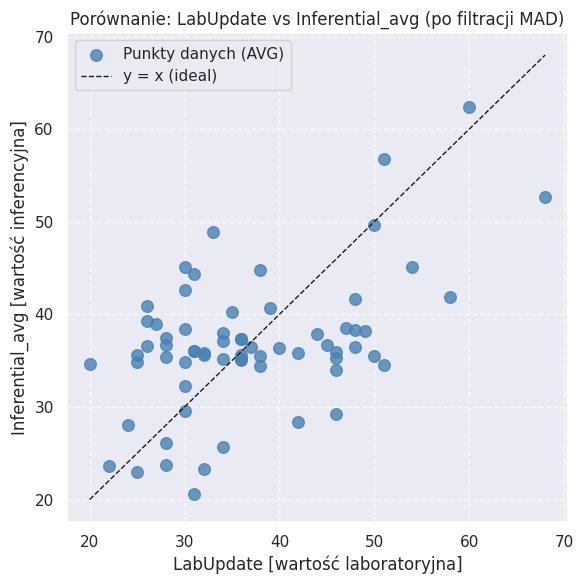

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Wykres XY: LabUpdate vs Inferential_avg ---
plt.figure(figsize=(6,6))
plt.scatter(
    df_clean_avg['LabUpdate'],
    df_clean_avg['Inferential_avg'],
    color='steelblue',
    s=70,
    alpha=0.8,
    label='Punkty danych (AVG)'
)

# linia idealna y = x
min_val = min(df_clean_avg['LabUpdate'].min(), df_clean_avg['Inferential_avg'].min())
max_val = max(df_clean_avg['LabUpdate'].max(), df_clean_avg['Inferential_avg'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='y = x (ideal)')

plt.title('Porównanie: LabUpdate vs Inferential_avg (po filtracji MAD)')
plt.xlabel('LabUpdate [wartość laboratoryjna]')
plt.ylabel('Inferential_avg [wartość inferencyjna]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


📈 Regresja liniowa (Inferential_avg = a·LabUpdate + b):
   a = 0.3741
   b = 22.9717
   R (Pearson) = 0.5086
   R² = 0.2587
   p-value = 1.299e-05


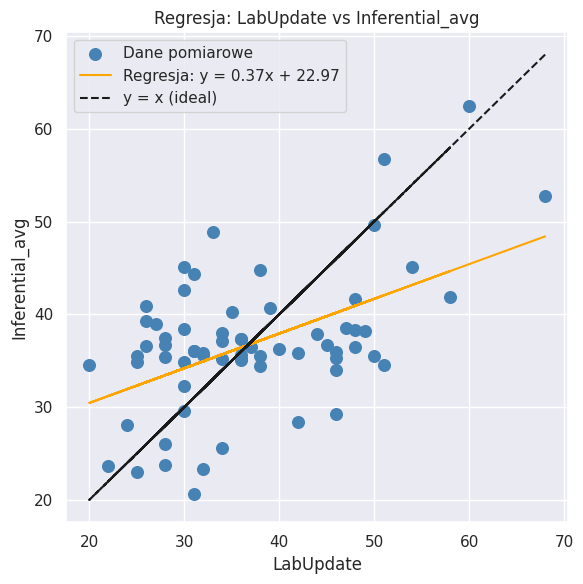

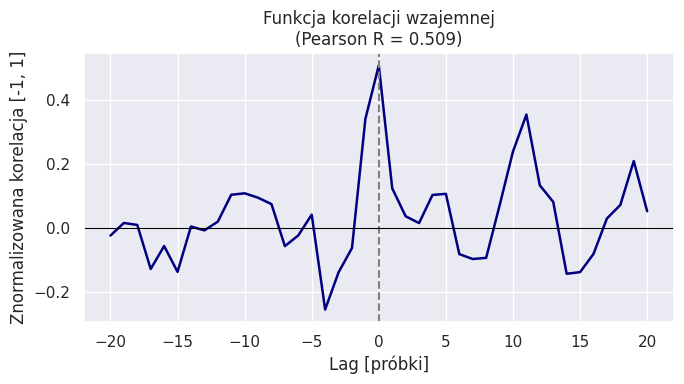

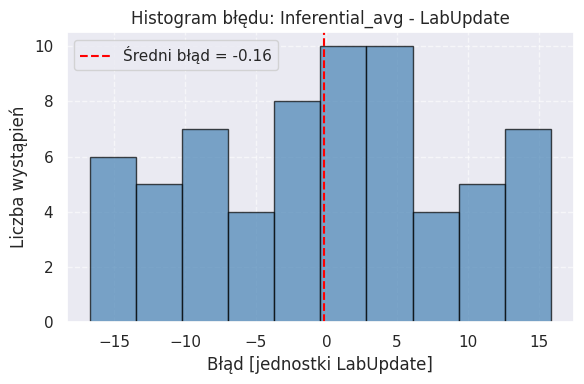

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# =====================================================
# 1. Przygotowanie danych
# =====================================================
x = df_clean_avg['LabUpdate'].values.reshape(-1, 1)
y = df_clean_avg['Inferential_avg'].values

# =====================================================
# 2. Regresja liniowa
# =====================================================
model = LinearRegression()
model.fit(x, y)

a = model.coef_[0]
b = model.intercept_
y_pred = model.predict(x)

# =====================================================
# 3. Współczynnik korelacji Pearsona
# =====================================================
r, p_val = pearsonr(df_clean_avg['LabUpdate'], df_clean_avg['Inferential_avg'])

print("📈 Regresja liniowa (Inferential_avg = a·LabUpdate + b):")
print(f"   a = {a:.4f}")
print(f"   b = {b:.4f}")
print(f"   R (Pearson) = {r:.4f}")
print(f"   R² = {r**2:.4f}")
print(f"   p-value = {p_val:.3e}")

# =====================================================
# 4. Wykres regresji
# =====================================================
plt.figure(figsize=(6,6))
plt.scatter(x, y, color='steelblue', label='Dane pomiarowe', s=70)
plt.plot(x, y_pred, color='orange', label=f'Regresja: y = {a:.2f}x + {b:.2f}')
plt.plot(x, x, 'k--', label='y = x (ideal)')
plt.title('Regresja: LabUpdate vs Inferential_avg')
plt.xlabel('LabUpdate')
plt.ylabel('Inferential_avg')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# 5. Funkcja korelacji wzajemnej
# =====================================================

def crosscorr_normalized(x, y, max_lag=None):
    """
    Zwraca znormalizowaną funkcję korelacji wzajemnej ([-1, 1])
    """
    x = np.asarray(x) - np.nanmean(x)
    y = np.asarray(y) - np.nanmean(y)
    n = len(x)
    if max_lag is None:
        max_lag = n - 1

    corr = np.correlate(x, y, mode='full')
    corr /= np.nanstd(x) * np.nanstd(y) * n
    lags = np.arange(-n + 1, n)
    center = len(corr) // 2
    idx = slice(center - max_lag, center + max_lag + 1)
    return lags[idx], corr[idx]

lags, corr_func = crosscorr_normalized(df_clean_avg['LabUpdate'], df_clean_avg['Inferential_avg'], max_lag=20)

plt.figure(figsize=(7,4))
plt.plot(lags, corr_func, color='navy', lw=1.8)
plt.axvline(0, color='grey', linestyle='--')
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'Funkcja korelacji wzajemnej\n(Pearson R = {r:.3f})')
plt.xlabel('Lag [próbki]')
plt.ylabel('Znormalizowana korelacja [-1, 1]')
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# 6. Histogram błędu (różnica Inferential - LabUpdate)
# =====================================================
error = df_clean_avg['Inferential_avg'] - df_clean_avg['LabUpdate']

plt.figure(figsize=(6,4))
plt.hist(error, bins=10, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(error.mean(), color='red', linestyle='--', label=f"Średni błąd = {error.mean():.2f}")
plt.title('Histogram błędu: Inferential_avg - LabUpdate')
plt.xlabel('Błąd [jednostki LabUpdate]')
plt.ylabel('Liczba wystąpień')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Modele regresji

Zbiór treningowy: 49 próbek
Zbiór testowy:    17 próbek

📈 Wyniki regresji liniowej (cechy: pH_avg, Ratio_avg → LabUpdate)
 Współczynniki regresji: [ 11.3195 142.1365]
 Wyraz wolny (intercept): -118.0321
 MAE train = 6.9263, test = 9.7844
 MSE train = 69.9692, test = 146.7609
 R²  train = 0.1256, test = -0.0301


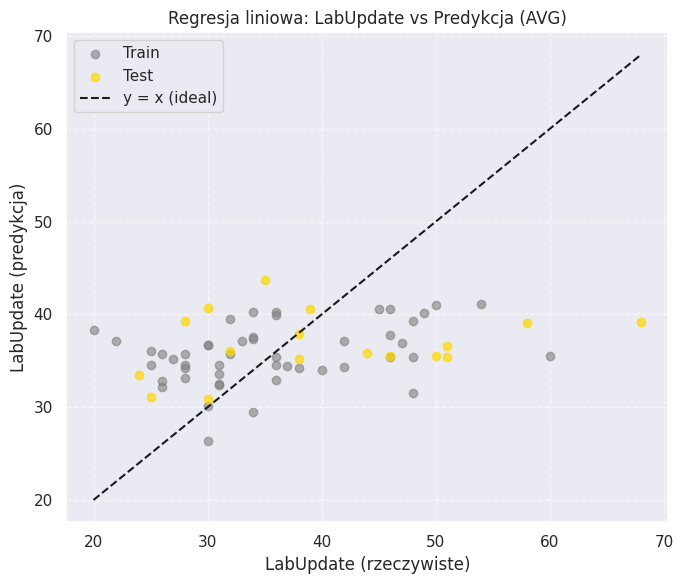


🔹 Współczynnik korelacji (test): 0.2480


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# 1. Dane wejściowe i target
# =====================================================
X = df_clean_avg[['pH_avg', 'Ratio_avg']]
y = df_clean_avg['LabUpdate']

# =====================================================
# 2. Podział na dane uczące i testowe
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Zbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy:    {X_test.shape[0]} próbek")

# =====================================================
# 3. Regresja liniowa
# =====================================================
model = LinearRegression()
model.fit(X_train, y_train)

# Predykcja
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# =====================================================
# 4. Metryki jakości
# =====================================================
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test  = mean_absolute_error(y_test,  y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test,  y_test_pred)
r2_train  = r2_score(y_train, y_train_pred)
r2_test   = r2_score(y_test,  y_test_pred)

print("\n📈 Wyniki regresji liniowej (cechy: pH_avg, Ratio_avg → LabUpdate)")
print(f" Współczynniki regresji: {model.coef_}")
print(f" Wyraz wolny (intercept): {model.intercept_:.4f}")
print(f" MAE train = {mae_train:.4f}, test = {mae_test:.4f}")
print(f" MSE train = {mse_train:.4f}, test = {mse_test:.4f}")
print(f" R²  train = {r2_train:.4f}, test = {r2_test:.4f}")

# =====================================================
# 5. Wykres: rzeczywiste vs przewidziane wartości
# =====================================================
plt.figure(figsize=(7,6))
plt.scatter(y_train, y_train_pred, label='Train', color='grey', alpha=0.6)
plt.scatter(y_test,  y_test_pred,  label='Test',  color='gold', alpha=0.7)

# linia idealna
mn = min(y.min(), y_train_pred.min(), y_test_pred.min())
mx = max(y.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([mn, mx], [mn, mx], 'k--', label='y = x (ideal)')

plt.title('Regresja liniowa: LabUpdate vs Predykcja (AVG)')
plt.xlabel('LabUpdate (rzeczywiste)')
plt.ylabel('LabUpdate (predykcja)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# =====================================================
# 6. Współczynnik korelacji między predykcją a LabUpdate
# =====================================================
corr_pred = np.corrcoef(y_test, y_test_pred)[0,1]
print(f"\n🔹 Współczynnik korelacji (test): {corr_pred:.4f}")


In [ ]:
# --- Podgląd danych po filtrze MAD (AVG) ---
print("📘 Zbiór df_clean_avg – dane po filtracji MAD:")
display(df_clean_avg.head(100))  # pierwsze 10 wierszy

print("\n📊 Informacje o strukturze danych:")
print(df_clean_avg.info())

print("\n📈 Podstawowe statystyki liczbowe:")
display(df_clean_avg.describe())

📘 Zbiór df_clean_avg – dane po filtracji MAD:


,ChangeTime,LabUpdate,Inferential_avg,Inferential_med,Ratio_avg,Ratio_med,pH_avg,pH_med,CMFlow_avg,CMFlow_med,error_avg,error_med
1,2025-10-16 03:02:30,68,52.716789,51.086988,0.380589,0.380293,9.113029,9.113763,52.384711,51.075890,-15.283211,-16.913012
2,2025-10-16 06:33:30,60,62.417553,63.746540,0.355859,0.356622,9.092202,9.092872,62.594202,64.000793,2.417553,3.746540
3,2025-10-16 08:32:30,31,44.393719,46.672949,0.342781,0.342676,9.090918,9.092872,45.917518,46.836266,13.393719,15.672949
4,2025-10-16 10:35:40,32,23.317020,23.991943,0.357975,0.357905,9.116514,9.113763,24.136728,24.367920,-8.682980,-8.008057
5,2025-10-16 12:45:30,31,20.612278,21.007409,0.340584,0.338621,9.017561,9.018521,21.072824,21.404186,-10.387722,-9.992591
...,...,...,...,...,...,...,...,...,...,...,...,...
69,2025-10-22 15:21:10,32,35.810713,36.700827,0.410185,0.410933,8.765192,8.770276,33.776858,34.078671,3.810713,4.700827
70,2025-10-22 19:17:30,35,40.211526,40.050809,0.438227,0.438268,8.782098,8.780723,39.851783,39.803432,5.211526,5.050809
74,2025-10-23 02:27:10,51,56.762327,57.413100,0.387047,0.386948,8.796699,8.796699,57.402580,57.578510,5.762327,6.413100
75,2025-10-23 04:29:00,30,45.059917,38.029393,0.357944,0.357957,8.596300,8.601298,42.772983,40.793915,15.059917,8.029393



📊 Informacje o strukturze danych:
<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 1 to 76
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ChangeTime       66 non-null     datetime64[ns]
 1   LabUpdate        66 non-null     int64         
 2   Inferential_avg  66 non-null     float64       
 3   Inferential_med  66 non-null     float64       
 4   Ratio_avg        66 non-null     float64       
 5   Ratio_med        66 non-null     float64       
 6   pH_avg           66 non-null     float64       
 7   pH_med           66 non-null     float64       
 8   CMFlow_avg       66 non-null     float64       
 9   CMFlow_med       66 non-null     float64       
 10  error_avg        66 non-null     float64       
 11  error_med        66 non-null     float64       
dtypes: datetime64[ns](1), float64(10), int64(1)
memory usage: 6.7 KB
None

📈 Podstawowe statystyki liczbowe:


,ChangeTime,LabUpdate,Inferential_avg,Inferential_med,Ratio_avg,Ratio_med,pH_avg,pH_med,CMFlow_avg,CMFlow_med,error_avg,error_med
count,66,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,2025-10-19 16:54:30.909090816,36.954545,36.795141,36.810721,0.369415,0.369379,8.971518,8.971384,36.831135,36.863383,-0.159405,-0.143825
min,2025-10-16 03:02:30,20.000000,20.612278,21.007409,0.306806,0.306751,8.596300,8.601298,21.072824,21.404186,-16.744561,-18.002229
25%,2025-10-18 01:12:55,30.000000,34.841395,34.708384,0.356445,0.356672,8.866258,8.866748,34.732446,34.478077,-8.353537,-8.070810
50%,2025-10-19 15:29:10,34.500000,36.172216,36.109264,0.365205,0.365215,9.017246,9.016063,36.181700,36.117065,0.441691,0.367322
75%,2025-10-21 13:38:57.500000,45.750000,38.886998,38.645196,0.382222,0.382230,9.074575,9.075512,39.504301,39.499082,5.624627,6.263254
max,2025-10-23 06:35:00,68.000000,62.417553,63.746540,0.438227,0.438268,9.116514,9.113763,62.594202,64.000793,15.875388,17.348095
std,NaN,10.089495,7.420471,7.526948,0.021620,0.021702,0.122448,0.122411,7.488978,7.566658,8.983497,9.572231


zapisz dane do pliku

In [ ]:
# =====================================================
# Zapis df_clean_avg do plików Excel i CSV
# =====================================================

# nazwy plików
excel_path = "df_clean_avg.xlsx"
csv_path   = "df_clean_avg.csv"

# zapis do Excela
df_clean_avg.to_excel(excel_path, index=False)

# zapis do CSV (UTF-8, separator ;)
df_clean_avg.to_csv(csv_path, index=False, sep=';', encoding='utf-8')

print("✅ Dane zapisane poprawnie:")
print(f"📘 Excel: {excel_path}")
print(f"📄 CSV:   {csv_path}")


✅ Dane zapisane poprawnie:
📘 Excel: df_clean_avg.xlsx
📄 CSV:   df_clean_avg.csv
